In [2]:
import pandas as pd

def load_features_from_csv(input_file):
    # Memuat file CSV
    data = pd.read_csv(input_file)

    # Memisahkan fitur (kolom selain label) dan label
    features = data.drop(columns=['label']).values
    labels = data['label'].values

    return features, labels

# Memuat fitur dan label dari file CSV
train_hog_features, train_labels = load_features_from_csv("hog_train_features4.csv")
test_hog_features, test_labels = load_features_from_csv("hog_test_features4.csv")

# Pastikan fitur dan label dimuat dengan benar
print("Train Features Shape:", train_hog_features.shape)
print("Test Features Shape:", test_hog_features.shape)


Train Features Shape: (3955, 108900)
Test Features Shape: (989, 108900)


In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Standarisasi fitur
scaler = StandardScaler()
train_hog_features_scaled = scaler.fit_transform(train_hog_features)
test_hog_features_scaled = scaler.transform(test_hog_features)

# Inisialisasi PCA untuk menghitung variansi kumulatif
pca_temp = PCA()
pca_temp.fit(train_hog_features_scaled)

# Hitung variansi kumulatif
cumulative_variance = np.cumsum(pca_temp.explained_variance_ratio_)

# Cari jumlah komponen untuk menjelaskan 95% variansi
n_components = np.argmax(cumulative_variance >= 0.99) + 1
print(f"Jumlah komponen PCA yang menjelaskan 98% variansi: {n_components}")

# Terapkan PCA dengan jumlah komponen terbaik
pca = PCA(n_components=n_components)
train_hog_features_pca = pca.fit_transform(train_hog_features_scaled)
test_hog_features_pca = pca.transform(test_hog_features_scaled)

# Output bentuk baru dari fitur
print(f"Train Features Shape after PCA: {train_hog_features_pca.shape}")
print(f"Test Features Shape after PCA: {test_hog_features_pca.shape}")


Jumlah komponen PCA yang menjelaskan 98% variansi: 3541
Train Features Shape after PCA: (3955, 3541)
Test Features Shape after PCA: (989, 3541)


In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Definisikan rentang parameter untuk GridSearchCV
param_grid = {
    'C': [10],
    'kernel': ['rbf']
}

# Inisialisasi model SVM
svc = SVC(probability=True)

# Set up GridSearchCV dengan cross-validation 5-fold
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit grid search pada data training
grid_search.fit(train_hog_features_pca, train_labels)

# Menampilkan hasil terbaik
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

# Menggunakan model terbaik untuk prediksi pada data testing
best_svc = grid_search.best_estimator_
y_pred = best_svc.predict(test_hog_features_pca)

# Evaluasi akurasi model
print("Test set accuracy: ", accuracy_score(test_labels, y_pred))


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters found:  {'C': 10, 'kernel': 'rbf'}
Best cross-validation score:  0.6690265486725664
Test set accuracy:  0.6946410515672397


Confusion Matrix:
 [[120  13  35  17  14]
 [  8 173  10   2   4]
 [ 21  19 130  14  15]
 [ 10   9  24 133  19]
 [ 12  18  17  21 131]]


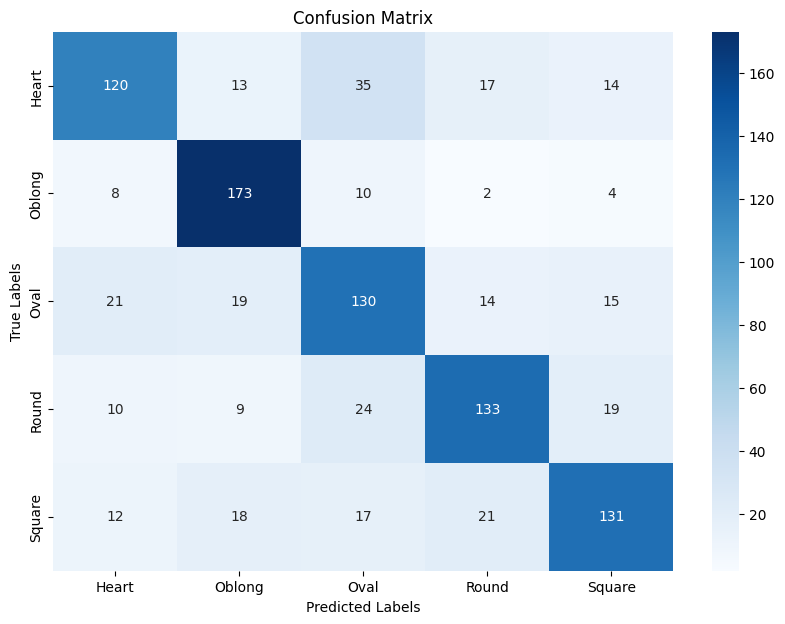

Classification Report:
               precision    recall  f1-score   support

       Heart       0.70      0.60      0.65       199
      Oblong       0.75      0.88      0.81       197
        Oval       0.60      0.65      0.63       199
       Round       0.71      0.68      0.70       195
      Square       0.72      0.66      0.69       199

    accuracy                           0.69       989
   macro avg       0.70      0.69      0.69       989
weighted avg       0.70      0.69      0.69       989



In [5]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat confusion matrix
cm = confusion_matrix(test_labels, y_pred)
print("Confusion Matrix:\n", cm)
# Visualisasi confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_svc.classes_, yticklabels=best_svc.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Laporan klasifikasi
print("Classification Report:\n", classification_report(test_labels, y_pred))

In [6]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import accuracy_score
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout
# from tensorflow.keras.optimizers import Adam
# import numpy as np

# from sklearn.preprocessing import LabelEncoder

# # Encode string labels as integers
# label_encoder = LabelEncoder()
# train_labels = label_encoder.fit_transform(train_labels)
# test_labels = label_encoder.transform(test_labels)

# # Fungsi untuk membangun model neural network
# def create_model(optimizer):
#     model = Sequential()
#     model.add(Dense(512, activation='relu', input_shape=(train_hog_features_pca.shape[1],)))
#     model.add(Dropout(0.5))
#     model.add(Dense(128, activation='relu'))
#     model.add(Dropout(0.5))
#     model.add(Dense(128, activation='relu'))
#     model.add(Dropout(0.5))
#     model.add(Dense(64, activation='relu'))
#     model.add(Dense(len(np.unique(train_labels)), activation='softmax'))

#     model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#     return model

# # Membuat dan melatih model neural network
# model = create_model(optimizer='sgd')

# # Melatih model
# history = model.fit(
#     train_hog_features_pca, train_labels,
#     epochs=500,
#     batch_size=128,
#     verbose=1
# )

# # Menggunakan model untuk prediksi pada data testing
# y_pred = np.argmax(model.predict(test_hog_features_pca), axis=1)

# # Evaluasi akurasi model
# print("Test set accuracy: ", accuracy_score(test_labels, y_pred))


In [7]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# # Membuat confusion matrix
# cm = confusion_matrix(test_labels, y_pred)

# # Membuat heatmap dengan seaborn
# plt.figure(figsize=(10, 7))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
# plt.xlabel('Predicted Labels')
# plt.ylabel('True Labels')
# plt.title('Confusion Matrix')
# plt.show()


In [8]:
# from sklearn.metrics import confusion_matrix, classification_report
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Membuat confusion matrix
# cm = confusion_matrix(test_labels, y_pred)
# print("Confusion Matrix:\n", cm)
# # Visualisasi confusion matrix
# plt.figure(figsize=(10, 7))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_svc.classes_, yticklabels=best_svc.classes_)
# plt.xlabel('Predicted Labels')
# plt.ylabel('True Labels')
# plt.title('Confusion Matrix')
# plt.show()

# # Laporan klasifikasi
# print("Classification Report:\n", classification_report(test_labels, y_pred))

In [9]:
import joblib
# Simpan model ke file
joblib.dump(best_svc, 'hog_model4.pkl')

print("Model berhasil disimpan!")

Model berhasil disimpan!


In [10]:
import joblib
scaler = StandardScaler()
scaler = scaler.fit(train_hog_features)
# Simpan Scaler
joblib.dump(scaler, 'scaler_hog4.pkl')

# Simpan PCA
joblib.dump(pca, 'pca_model_hog4.pkl')


['pca_model_hog4.pkl']